In [1]:
!pip install fredapi

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from fredapi import Fred

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox


In [3]:
# Nacitanie zo suboru

df = pd.read_csv('data.csv', index_col = 'Date', parse_dates = True)
df.index.freq = 'MS' # mesačná frekvencia

In [4]:
print(df.head())
print(f"\nPočet pozorovaní: {len(df)}")
print(f"Obdobie: {df.index[0].date()} až {df.index[-1].date()}")

            EURUSD
Date              
2000-01-01  1.0131
2000-02-01  0.9834
2000-03-01  0.9643
2000-04-01  0.9449
2000-05-01  0.9059

Počet pozorovaní: 312
Obdobie: 2000-01-01 až 2025-12-01


# --- 1.1 Transformacia ---

In [5]:
df_diff = df.copy()
df_diff['log_EURUSD'] = np.log(df_diff['EURUSD'])
df_diff['dlog_EURUSD'] = df_diff['log_EURUSD'].diff()
df_diff['d_EURUSD'] = df_diff['EURUSD'].diff()
df_diff = df_diff.dropna() # zahodi prve NaN

In [6]:
df_diff

,EURUSD,log_EURUSD,dlog_EURUSD,d_EURUSD
Date,,,,
2000-02-01,0.9834,-0.016739,-0.029754,-0.0297
2000-03-01,0.9643,-0.036353,-0.019614,-0.0191
2000-04-01,0.9449,-0.056676,-0.020323,-0.0194
2000-05-01,0.9059,-0.098826,-0.042150,-0.0390
2000-06-01,0.9505,-0.050767,0.048059,0.0446
...,...,...,...,...
2025-08-01,1.1647,0.152464,-0.002058,-0.0024
2025-09-01,1.1739,0.160332,0.007868,0.0092
2025-10-01,1.1641,0.151948,-0.008383,-0.0098


# --- 1.2 Vizualizacia ---

In [7]:
def plot_series(data, title = '', ylabel = '', color = 'blue', hline = True, savefig = ''):
    plt.figure(figsize = (12,3))
    plt.plot(data, color=color, linewidth=1.2)
    plt.title(title, fontsize=13)
    plt.ylabel(ylabel)
    plt.axhline(data.mean(), color='red', linestyle='--',
               linewidth=0.8, label='priemer')
    plt.tight_layout()
    if (savefig != ''): 
        plt.savefig(savefig, dpi=150)
    plt.show()

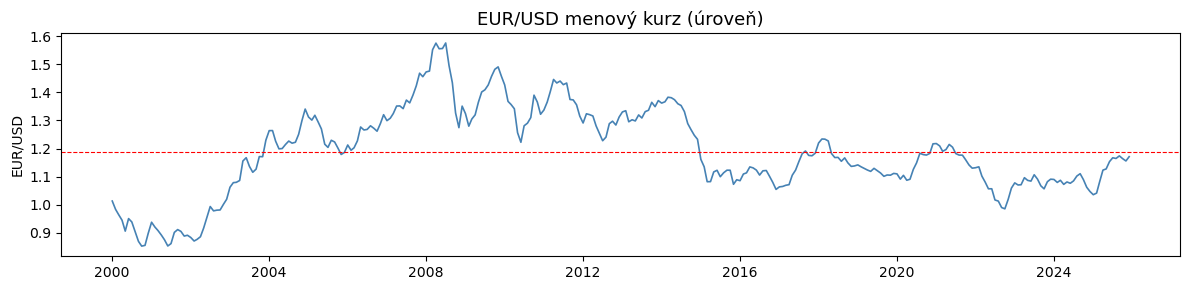

In [8]:
plot_series(df['EURUSD'], 'EUR/USD menový kurz (úroveň)', 'EUR/USD', 'steelblue', savefig='basic.png')

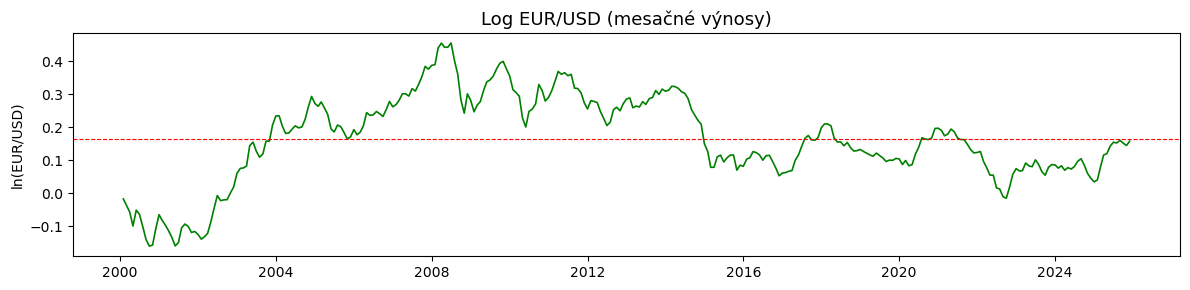

In [9]:
plot_series(df_diff['log_EURUSD'], 'Log EUR/USD (mesačné výnosy)', 'ln(EUR/USD)', 'green', savefig='log.png')

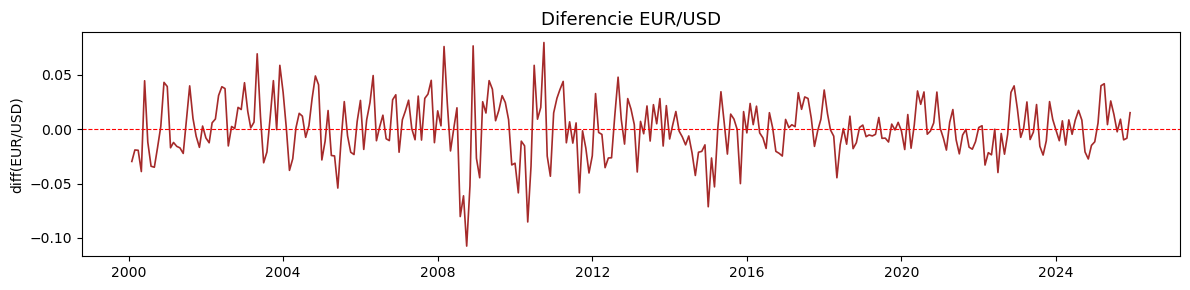

In [10]:
plot_series(df_diff['d_EURUSD'], 'Diferencie EUR/USD', 'diff(EUR/USD)', 'brown', savefig='diff.png')

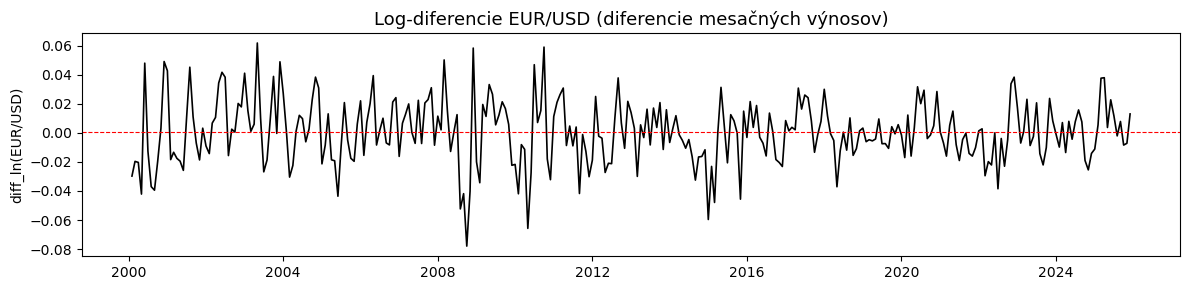

In [11]:
plot_series(df_diff['dlog_EURUSD'], 'Log-diferencie EUR/USD (diferencie mesačných výnosov)', 'diff_ln(EUR/USD)', 'black', savefig = 'log_diff.png')

# --- 1.3: ACF a PACF ---

## ACF / PACF for basic

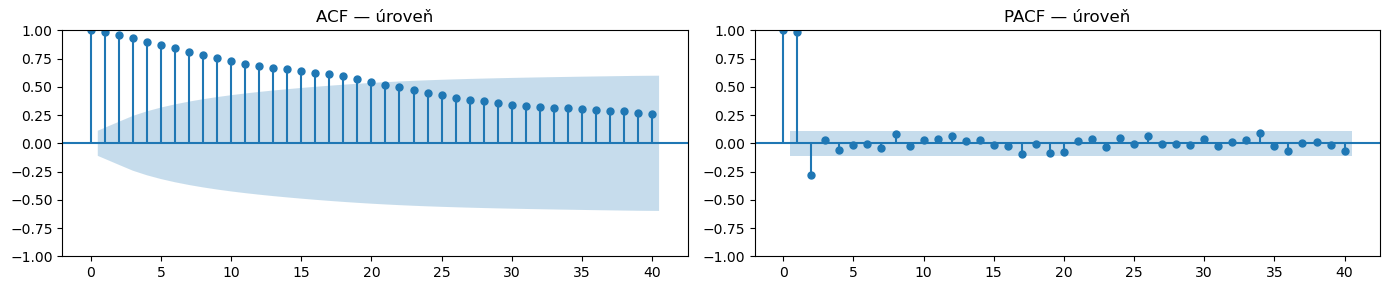

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# Basic
plot_acf(df_diff['EURUSD'], lags=40, ax=axes[0], title='ACF — úroveň')
plot_pacf(df_diff['EURUSD'], lags=40, ax=axes[1], title='PACF — úroveň')

plt.tight_layout()
plt.savefig('basic_acf_pacf.png', dpi=150)
plt.show()

## ACF / PACF for log-diff

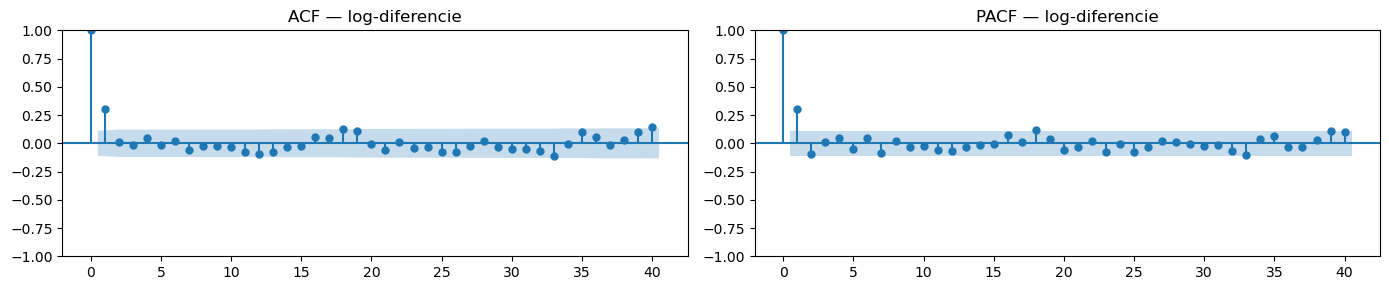

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# Log-diferencie
plot_acf(df_diff['dlog_EURUSD'], lags=40, ax=axes[0],
         title='ACF — log-diferencie')
plot_pacf(df_diff['dlog_EURUSD'], lags=40, ax=axes[1],
          title='PACF — log-diferencie')

plt.tight_layout()
plt.savefig('dlog_acf_pacf.png', dpi=150)
plt.show()

# --- 2.1 ARMA modely ---

In [14]:
df_diff.shape

(311, 4)

In [15]:
y = df_diff['dlog_EURUSD']

# --- 1. Odhad modelov ---
models_spec = {
    'AR(1)'    : (1, 0, 0),
    'MA(1)'    : (0, 0, 1),
    'ARMA(1,1)': (1, 0, 1),
}

fitted_models = {}
for name, order in models_spec.items():
    model = ARIMA(y, order=order)
    fitted_models[name] = model.fit()
    print(f"\n{'='*78}")
    print(f"Model: {name}")
    print(fitted_models[name].summary().tables[1])


Model: AR(1)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.002      0.257      0.798      -0.003       0.004
ar.L1          0.3065      0.050      6.184      0.000       0.209       0.404
sigma2         0.0004   2.93e-05     14.577      0.000       0.000       0.000

Model: MA(1)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.002      0.292      0.771      -0.003       0.003
ma.L1          0.3219      0.056      5.775      0.000       0.213       0.431
sigma2         0.0004    2.9e-05     14.622      0.000       0.000       0.000

Model: ARMA(1,1)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const 

In [16]:
rows = []
for name, res in fitted_models.items():
    params = dict(zip(res.param_names, res.params))
    pvals  = dict(zip(res.param_names, res.pvalues))
    for param in res.param_names:
        rows.append({
            'Parameter': param,
            'Model'    : name,
            'coef'     : round(params[param], 4),
            'p-value'  : round(pvals[param],  4),
        })

df_params = pd.DataFrame(rows)

# Pivot: riadky = parametre, stlpce = modely
coef_tbl  = df_params.pivot(index='Parameter', columns='Model', values='coef')
pval_tbl  = df_params.pivot(index='Parameter', columns='Model', values='p-value')

# Zlep do jednej tabulky: striedaj coef a p-value pre kazdy model
combined = pd.concat(
    {name: pd.DataFrame({'coef': coef_tbl[name], 'p': pval_tbl[name]})
     for name in fitted_models},
    axis=1
)

# Poradie parametrov
param_order = ['const', 'ar.L1', 'ma.L1', 'sigma2']
combined = combined.reindex(param_order)
combined = combined.fillna('').to_string()

print(combined)

            AR(1)           MA(1)         ARMA(1,1)        
             coef       p    coef       p      coef       p
Parameter                                                  
const      0.0004  0.7975  0.0005  0.7706    0.0005  0.7758
ar.L1      0.3065     0.0                    0.0255  0.8446
ma.L1                      0.3219     0.0    0.3079  0.0170
sigma2     0.0004     0.0  0.0004     0.0    0.0004  0.0000


# --- 2.2 Diagnostika: Ljung-Box test na rezidua ---

In [17]:

print("\n\n=== DIAGNOSTIKA: Ljung-Box test (H0: rezidua su biely sum) ===")
lags_to_test = [6, 12, 24]

diag_rows = []
for name, res in fitted_models.items():
    row = {'Model': name}
    lb = acorr_ljungbox(res.resid, lags=lags_to_test, return_df=True)
    for lag in lags_to_test:
        row[f'LB p-val (lag {lag})'] = round(lb.loc[lag, 'lb_pvalue'], 4)
    # Informacne kriteria
    row['AIC'] = round(res.aic, 2)
    row['BIC'] = round(res.bic, 2)
    # In-sample fit
    row['RMSE'] = round(np.sqrt(np.mean(res.resid**2)), 6)
    row['MAE']  = round(np.mean(np.abs(res.resid)), 6)
    diag_rows.append(row)

diag_df = pd.DataFrame(diag_rows).set_index('Model')
print(diag_df.to_string())



=== DIAGNOSTIKA: Ljung-Box test (H0: rezidua su biely sum) ===
           LB p-val (lag 6)  LB p-val (lag 12)  LB p-val (lag 24)      AIC      BIC      RMSE       MAE
Model                                                                                                  
AR(1)                0.4937             0.7272             0.6783 -1524.27 -1513.05  0.020671  0.016156
MA(1)                0.6981             0.7896             0.6638 -1526.44 -1515.22  0.020599  0.016070
ARMA(1,1)            0.7044             0.8001             0.6755 -1524.60 -1509.64  0.020594  0.016076


## Grafy pre reziduá

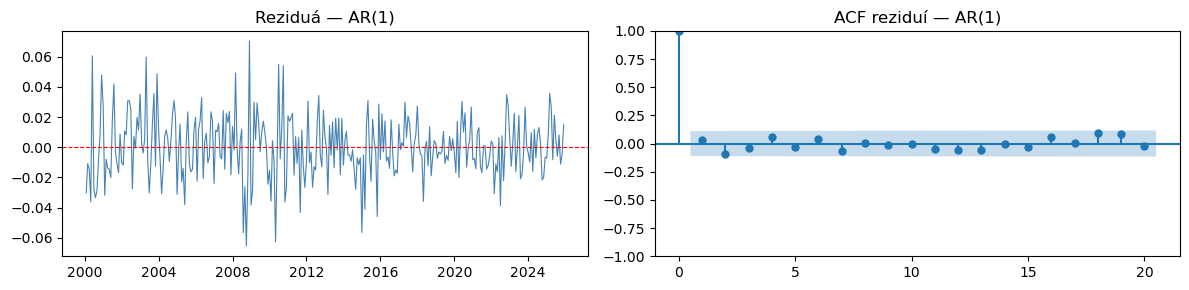

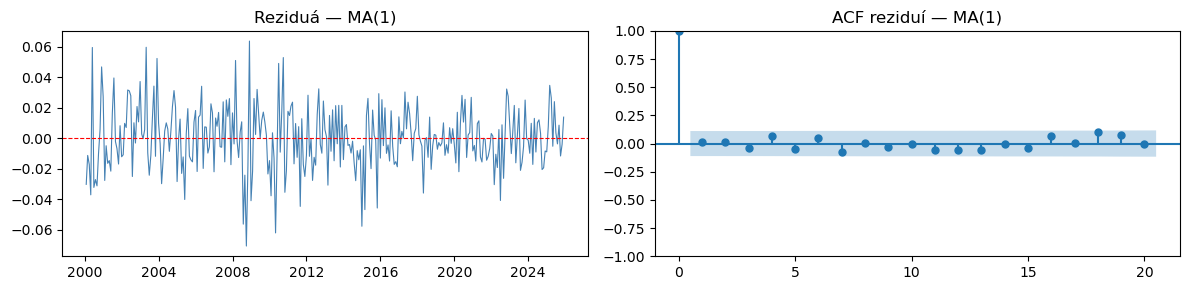

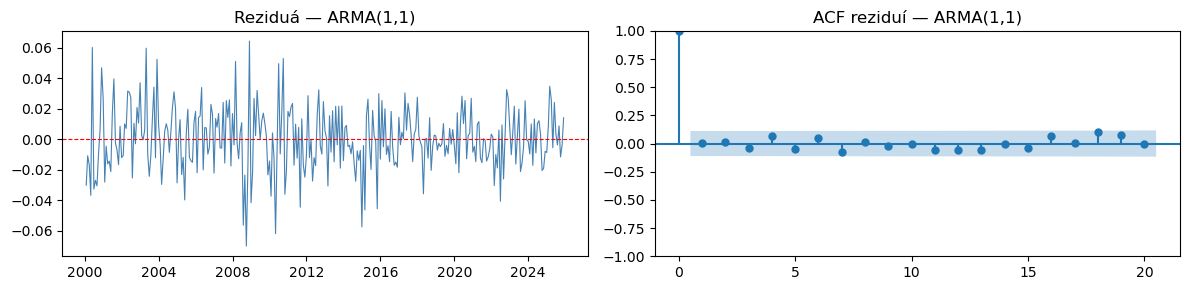

In [18]:
for name, res in fitted_models.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    
    # Rezidua
    axes[0].plot(res.resid, color='steelblue', linewidth=0.8)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[0].set_title(f'Reziduá — {name}')
    
    # Correlogram
    plot_acf(res.resid, lags=20, ax=axes[1], title=f'ACF reziduí — {name}')

    plt.tight_layout()
    plt.savefig(f'rezidua-{name}.png', dpi=150)    
    plt.show()

## Stabilita modelov

In [19]:
for name, res in fitted_models.items():
    print(f"""{name}: AR korene = {res.arroots}, MA korene = {res.maroots},
        stabilný = {all(abs(res.arroots) > 1) & all(abs(res.maroots) > 1)}""")

AR(1): AR korene = [3.26302848], MA korene = [],
        stabilný = True
MA(1): AR korene = [], MA korene = [-3.10690097],
        stabilný = True
ARMA(1,1): AR korene = [39.27236629], MA korene = [-3.2481124],
        stabilný = True


# --- 2.3 Vyrovnane hodnoty vs. skutocne ---

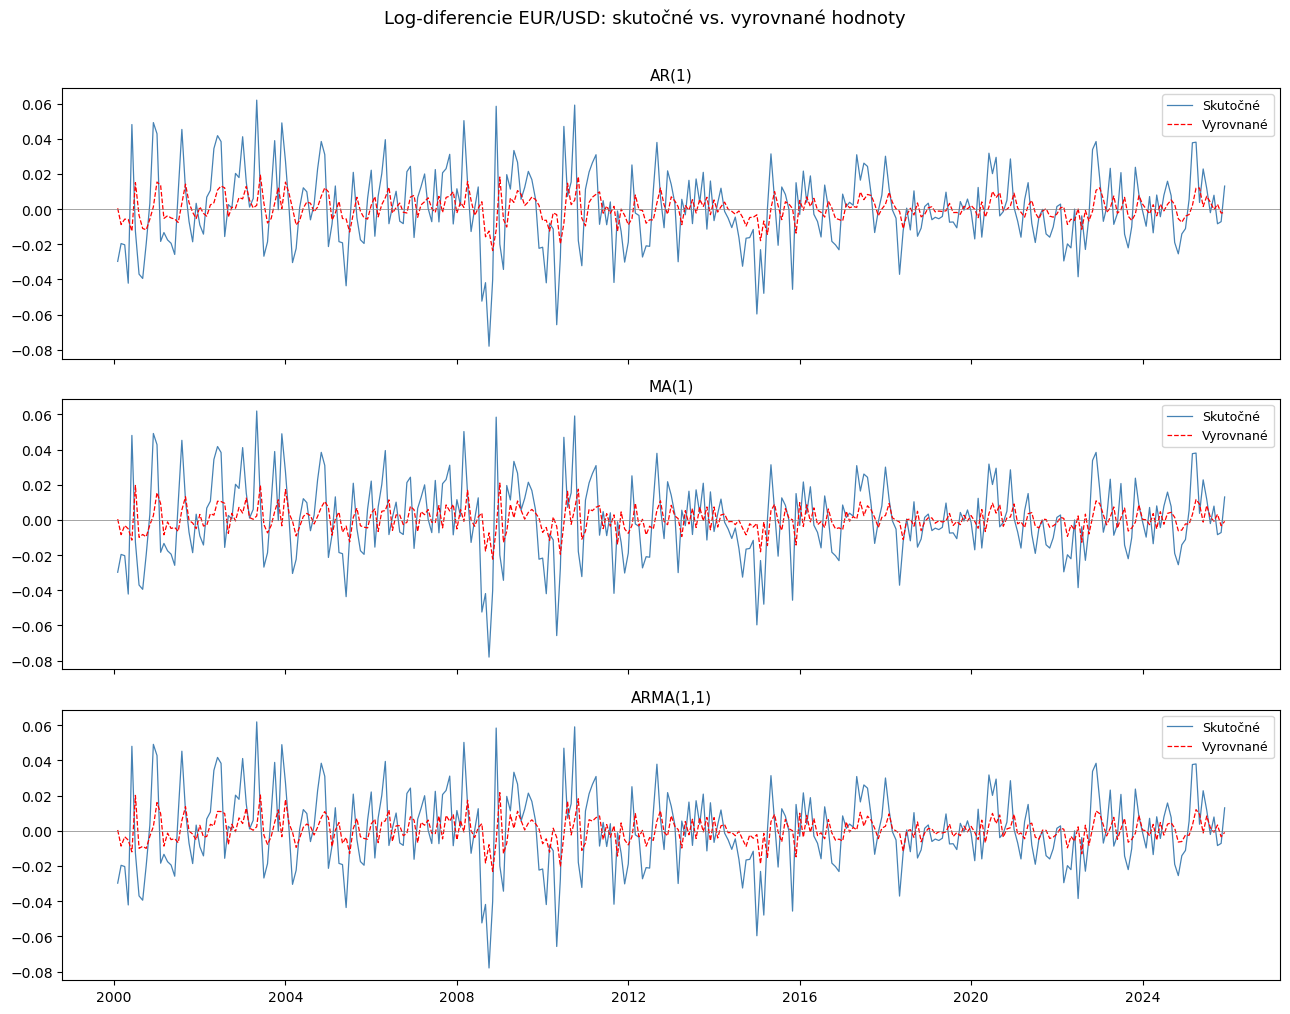

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, (name, res) in zip(axes, fitted_models.items()):
    ax.plot(y.index, y.values, color='steelblue',
            linewidth=0.9, label='Skutočné')
    ax.plot(y.index, res.fittedvalues, color='red',
            linewidth=0.9, linestyle='--', label='Vyrovnané')
    ax.set_title(f'{name}', fontsize=11)
    ax.legend(fontsize=9)
    ax.axhline(0, color='grey', linewidth=0.5)

plt.suptitle('Log-diferencie EUR/USD: skutočné vs. vyrovnané hodnoty',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fitted.png', dpi=150)
plt.show()


# --- 3 Predikcie ---

In [21]:
y = df_diff['dlog_EURUSD']
T = len(y)

# --- Nastavenia ---
models_spec = {
    'AR(1)'    : (1, 0, 0),
    'MA(1)'    : (0, 0, 1),
    'ARMA(1,1)': (1, 0, 1),
}
horizons = [1, 2, 3, 4]
T_out    = 60   # pocet out-of-sample pozorovaní (expanding + rolling)
T_in     = T - T_out  # zaciatok rekurzie


In [22]:
# ================================================================
# FUNKCIA: rekurzivne predikcie
# ================================================================
def recursive_forecasts(y, order, T_in, horizons, window_type='expanding'):
    """
    Vracia dict: horizon -> pole predikcii dlzky (T_out - horizon + 1)
    window_type: 'expanding' alebo 'rolling'
    
    pre každý časový bod t odhadne model na trénovacej vzorke (expanding alebo rolling okno) a urobí predikcie na horizonty h=1,2,3,4. Vracia slovník predikcií pre každý horizont
    """
    T = len(y)
    preds = {h: [] for h in horizons}

    for t in range(T_in, T):
        if window_type == 'expanding':
            y_train = y.iloc[:t]
        else:  # rolling - fixne okno rovnakej dlzky ako T_in
            y_train = y.iloc[t - T_in:t]

        try:
            res = ARIMA(y_train, order=order).fit()
            fc  = res.forecast(steps=max(horizons))
            for h in horizons:
                if t + h - 1 < T:
                    preds[h].append(float(fc.iloc[h - 1]))
        except Exception:
            for h in horizons:
                preds[h].append(np.nan)

    return preds

In [23]:
# ================================================================
# NAIVNY MODEL (random walk): predikcia = posledna pozorena hodnota
# ================================================================
def naive_forecasts(y, T_in, horizons):
    """
    ako predch, ale bez odhadovania modelu. Predikcia je vždy posledná pozorovaná hodnota y[t-1] — náhodná prechádzka.
    """
    T = len(y)
    preds = {h: [] for h in horizons}
    for t in range(T_in, T):
        for h in horizons:
            if t + h - 1 < T:
                preds[h].append(float(y.iloc[t - 1])) 
    return preds

In [24]:
# ================================================================
# LOSS FUNKCIE
# ================================================================
def compute_metrics(actual, predicted):
    e   = actual - predicted
    mae  = np.mean(np.abs(e))
    mse  = np.mean(e**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(e / actual)) * 100 if np.all(actual != 0) else np.nan
    return {'MAE': mae, 'RMSE': rmse, 'MSE': mse, 'MAPE': mape}

In [25]:
# ================================================================
# DIEBOLD-MARIANO TEST (jednoducha implementacia)
# ================================================================
def dm_test(e1, e2, h=1):
    """
    H0: oba modely maju rovnaku predikcnu schopnost
    e1, e2: chyby modelu 1 a 2
    Vracia: DM statistiku a p-hodnotu (dvojstranny test)
    """
    d   = e1**2 - e2**2   # rozdiel stvorcovych chyb
    T   = len(d)
    d_bar = np.mean(d)
    # HAC variancia (Newey-West, h lagov)
    gamma0 = np.var(d, ddof=0)
    gammas = sum(
        2 * (1 - k/(h+1)) * np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
        for k in range(1, h+1)
    )
    var_d = (gamma0 + gammas) / T
    if var_d <= 0:
        return np.nan, np.nan
    dm_stat = d_bar / np.sqrt(var_d)
    p_val   = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return round(dm_stat, 4), round(p_val, 4)

In [26]:
# ================================================================
# HLAVNA SLUCKA: expanding + rolling okno
# ================================================================
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

results = {}

for window in ['expanding', 'rolling']:
    results[window] = {}

    # Naivny model
    naive_preds = naive_forecasts(y, T_in, horizons)
    results[window]['Naive'] = {}
    for h in horizons:
        preds_h  = np.array(naive_preds[h], dtype=float)
        actual_h = np.array([float(y.iloc[T_in + i + h - 1]) for i in range(len(preds_h))])
        valid = ~np.isnan(preds_h) & ~np.isnan(actual_h)
        results[window]['Naive'][h] = compute_metrics(actual_h[valid], preds_h[valid])

    # ARMA modely
    for name, order in models_spec.items():
        results[window][name] = {}
        preds_all = recursive_forecasts(y, order, T_in, horizons, window)
        for h in horizons:
            preds_h  = np.array(preds_all[h], dtype=float)
            actual_h = np.array([float(y.iloc[T_in + i + h - 1]) for i in range(len(preds_h))])
            valid = ~np.isnan(preds_h) & ~np.isnan(actual_h)
            results[window][name][h] = compute_metrics(actual_h[valid], preds_h[valid])

In [27]:
# ================================================================
# TABULKA VYSLEDKOV
# ================================================================
print("\n" + "="*70)
for window in ['expanding', 'rolling']:
    print(f"\n>>> Okno: {window.upper()}")
    rows = []
    for model in ['AR(1)', 'MA(1)', 'ARMA(1,1)', 'Naive']:
        for h in horizons:
            m = results[window][model][h]
            rows.append({
                'Model': model, 'Horizont': h,
                'MAE'  : round(m['MAE'],  6),
                'RMSE' : round(m['RMSE'], 6),
                'MAPE' : round(m['MAPE'], 2),
            })
    tbl = pd.DataFrame(rows)
    print(tbl.pivot_table(
        index='Model', columns='Horizont',
        values='RMSE').to_string())



>>> Okno: EXPANDING
Horizont          1         2         3         4
Model                                            
AR(1)      0.015694  0.016990  0.017116  0.017107
ARMA(1,1)  0.015624  0.016959  0.017109  0.017114
MA(1)      0.015651  0.016986  0.017108  0.017114
Naive      0.019070  0.023625  0.024478  0.023800

>>> Okno: ROLLING
Horizont          1         2         3         4
Model                                            
AR(1)      0.015781  0.017103  0.017253  0.017238
ARMA(1,1)  0.015725  0.017088  0.017252  0.017250
MA(1)      0.015751  0.017122  0.017251  0.017250
Naive      0.019070  0.023625  0.024478  0.023800


In [28]:
print("\n" + "="*70)
for window in ['expanding', 'rolling']:
    print(f"\n>>> Okno: {window.upper()}")
    rows = []
    for model in ['AR(1)', 'MA(1)', 'ARMA(1,1)', 'Naive']:
        for h in horizons:
            m = results[window][model][h]
            rows.append({
                'Model': model, 'Horizont': h,
                'MAE'  : round(m['MAE'],  6),
                'RMSE' : round(m['RMSE'], 6),
            })
    tbl = pd.DataFrame(rows)
    for metric in ['RMSE', 'MAE']:
        print(f"\n--- {metric} ---")
        print(tbl.pivot_table(
            index='Model', columns='Horizont',
            values=metric).to_string())



>>> Okno: EXPANDING

--- RMSE ---
Horizont          1         2         3         4
Model                                            
AR(1)      0.015694  0.016990  0.017116  0.017107
ARMA(1,1)  0.015624  0.016959  0.017109  0.017114
MA(1)      0.015651  0.016986  0.017108  0.017114
Naive      0.019070  0.023625  0.024478  0.023800

--- MAE ---
Horizont          1         2         3         4
Model                                            
AR(1)      0.012687  0.013631  0.013665  0.013607
ARMA(1,1)  0.012611  0.013521  0.013664  0.013620
MA(1)      0.012621  0.013562  0.013668  0.013620
Naive      0.016070  0.019328  0.020129  0.018041

>>> Okno: ROLLING

--- RMSE ---
Horizont          1         2         3         4
Model                                            
AR(1)      0.015781  0.017103  0.017253  0.017238
ARMA(1,1)  0.015725  0.017088  0.017252  0.017250
MA(1)      0.015751  0.017122  0.017251  0.017250
Naive      0.019070  0.023625  0.024478  0.023800

--- MAE ---
Horiz

In [29]:
# ================================================================
# DIEBOLD-MARIANO: najlepsi ARMA (MA1) vs Naive, kazdy horizont
# ================================================================
print("\n\n=== DM TEST: MA(1) vs. Naive ===")
print(f"{'Horizont':<12} {'DM stat':<12} {'p-hodnota':<12} Záver")
print("-"*50)
for window in ['expanding', 'rolling']:
    print(f"\n  Okno: {window}")
    ma1_preds_all  = recursive_forecasts(y, (0,0,1), T_in, horizons, window)
    naive_preds_all = naive_forecasts(y, T_in, horizons)
    for h in horizons:
        p_ma1   = np.array(ma1_preds_all[h], dtype=float)
        p_naive = np.array(naive_preds_all[h], dtype=float)
        actual_h = np.array([float(y.iloc[T_in + i + h - 1]) for i in range(len(p_ma1))])
        valid = ~np.isnan(p_ma1) & ~np.isnan(p_naive) & ~np.isnan(actual_h)
        e_ma1  = actual_h[valid] - p_ma1[valid]
        e_naive = actual_h[valid] - p_naive[valid]
        dm, pv  = dm_test(e_ma1, e_naive, h=h)
        zaver   = "MA(1) lepší" if pv < 0.05 else "Nie je rozdiel"
        print(f"  h={h:<9} {dm:<12} {pv:<12} {zaver}")



=== DM TEST: MA(1) vs. Naive ===
Horizont     DM stat      p-hodnota    Záver
--------------------------------------------------

  Okno: expanding
  h=1         -3.4869      0.0005       MA(1) lepší
  h=2         -3.8774      0.0001       MA(1) lepší
  h=3         -3.4652      0.0005       MA(1) lepší
  h=4         -2.2873      0.0222       MA(1) lepší

  Okno: rolling
  h=1         -3.3203      0.0009       MA(1) lepší
  h=2         -3.7302      0.0002       MA(1) lepší
  h=3         -3.3719      0.0007       MA(1) lepší
  h=4         -2.2386      0.0252       MA(1) lepší


In [30]:
# ================================================================
# GRAF: najlepsi model (MA1) - bodova predikcia + PI mimo vzorky
# ================================================================
# Odhadneme MA(1) na celom datasete
final_model = ARIMA(y, order=(0, 0, 1)).fit()
n_ahead = 4
fc_res  = final_model.get_forecast(steps=n_ahead)
fc_mean = fc_res.predicted_mean
fc_ci   = fc_res.conf_int(alpha=0.05)  # 95% PI


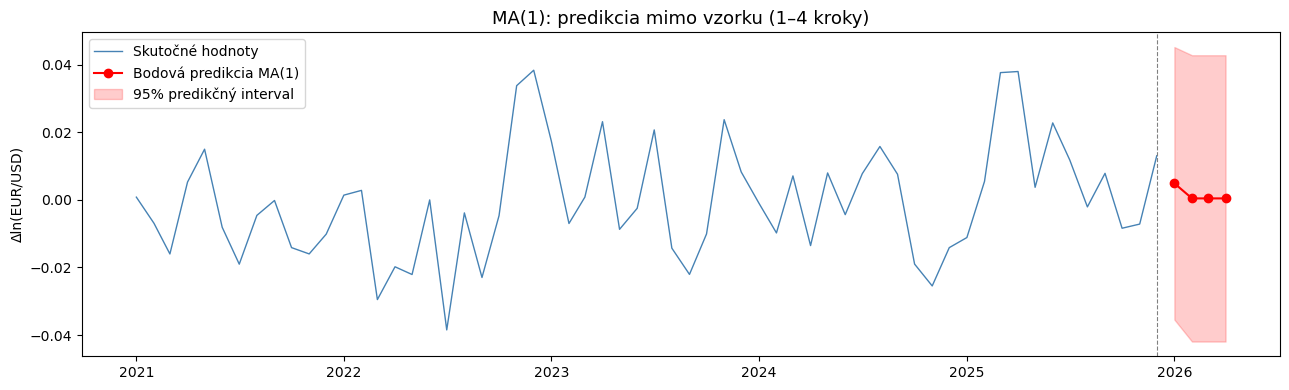

In [31]:
# Poslednych 60 pozorovaní + predikcia
y_plot = y.iloc[-60:]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_plot.index, y_plot.values,
        color='steelblue', linewidth=1.0, label='Skutočné hodnoty')

# Predikcia
future_idx = pd.date_range(y.index[-1], periods=n_ahead+1, freq='MS')[1:]
ax.plot(future_idx, fc_mean.values,
        color='red', linewidth=1.5, marker='o', label='Bodová predikcia MA(1)')
ax.fill_between(future_idx,
                fc_ci.iloc[:, 0].values,
                fc_ci.iloc[:, 1].values,
                color='red', alpha=0.2, label='95% predikčný interval')

ax.axvline(y.index[-1], color='grey', linestyle='--', linewidth=0.8)
ax.set_title('MA(1): predikcia mimo vzorku (1–4 kroky)', fontsize=13)
ax.set_ylabel('Δln(EUR/USD)')
ax.legend()
plt.tight_layout()
plt.savefig('eurusd_forecast.png', dpi=150)
plt.show()